In [132]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [133]:
def tenor_to_years(tenor: str) -> float:
    t = str(tenor).strip().upper()
    m = re.fullmatch(r"(\d+)\s*([DWMY])", t)
    if not m:
        raise ValueError(f"Could not parse tenor: {tenor}")
    n = int(m.group(1))
    u = m.group(2)
    if u == "D": return n / 365.0
    if u == "W": return n / 52.0
    if u == "M": return n / 12.0
    if u == "Y": return float(n)
    raise ValueError(f"Unknown tenor unit: {u}")

def load_curve_panel(path: str):
    df = pd.read_excel(path, index_col="date")
    df = df.dropna(how="any")  # keep only full rows
    # Parse tenors from columns
    tenors = list(df.columns)
    T = np.array([tenor_to_years(c) for c in tenors], dtype=float)
    idx = np.argsort(T)
    T = T[idx]
    df = df.iloc[:, idx]

    # Convert to decimals if needed
    X = df.values.astype(float)
    if np.nanmax(np.abs(X)) > 1.0:
        X = X / 100.0

    dates = df.index
    return dates, T, X, df

excel_path = "swaps.xlsx"  # <-- your file
dates, T_quote, S_panel, df_raw = load_curve_panel(excel_path)

print("n_dates:", len(dates))
print("n_tenors:", len(T_quote))
print("T range:", (T_quote.min(), T_quote.max()))
df_raw.head()


n_dates: 4430
n_tenors: 9
T range: (np.float64(0.0027397260273972603), np.float64(10.0))


,1d,90d,180d,1y,2y,3y,4y,5y,10y
date,,,,,,,,,
2008-01-02,6.0,6.103718,6.150008,6.110028,6.369943,6.410533,6.430828,6.451124,6.583043
2008-01-03,6.0,6.093868,6.145159,6.098267,6.380091,6.390238,6.410533,6.440976,6.562748
2008-01-04,6.0,6.172664,6.261514,6.213473,6.542452,6.562748,6.583043,6.603339,6.674373
2008-01-07,6.0,6.221904,6.348737,6.344976,6.725113,6.725113,6.714965,6.735261,6.816445
2008-01-08,6.0,6.300675,6.474658,6.420044,6.755557,6.786001,6.796149,6.836741,6.897630


In [134]:
def build_grid(T_quote, n_extra=200):
    T_max = float(np.max(T_quote))
    extra = np.linspace(0.0, T_max, n_extra)
    grid = np.unique(np.concatenate(([0.0], T_quote, extra)))
    grid.sort()
    return grid

T_grid = build_grid(T_quote, n_extra=300)
T_grid_t = torch.tensor(T_grid, device=device).reshape(-1, 1)

# Indices of quote tenors inside the grid (exact match because we included them)
quote_idx = np.searchsorted(T_grid, T_quote)
assert np.allclose(T_grid[quote_idx], T_quote)
quote_idx_t = torch.tensor(quote_idx, device=device, dtype=torch.long)

print("grid size:", len(T_grid))


grid size: 308


In [135]:
class CurveDataset(Dataset):
    def __init__(self, S_panel, standardize=True):
        self.S = torch.tensor(S_panel, dtype=torch.float64)
        self.standardize = standardize
        if standardize:
            self.mu = self.S.mean(dim=0, keepdim=True)
            self.sig = self.S.std(dim=0, keepdim=True).clamp_min(1e-8)
        else:
            self.mu = torch.zeros(1, self.S.shape[1], dtype=torch.float64)
            self.sig = torch.ones(1, self.S.shape[1], dtype=torch.float64)

    def __len__(self):
        return self.S.shape[0]

    def __getitem__(self, i):
        s = self.S[i]
        s_std = (s - self.mu[0]) / self.sig[0] if self.standardize else s
        return s_std, s

dataset = CurveDataset(S_panel, standardize=False)


In [136]:
n = len(dataset)
n_train = int(0.85 * n)
perm = np.random.permutation(n)
train_idx, test_idx = perm[:n_train], perm[n_train:]

train_ds = torch.utils.data.Subset(dataset, train_idx)
test_ds  = torch.utils.data.Subset(dataset, test_idx)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

len(train_ds), len(test_ds)


(3765, 665)

In [137]:
class PINN(nn.Module):
    def __init__(self, hidden=64, depth=4):
        super().__init__()
        layers = []
        in_dim = 1
        out_dim = 2  # [A_raw, g_raw]
        dims = [in_dim] + [hidden]*depth + [out_dim]
        for i in range(len(dims)-2):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, T):
        # T shape: (N,1)
        out = self.net(T)
        A = out[:, :1]                        # unconstrained
        g = out[:, 1:2]
        P = torch.exp(-g)                     # in (0,1]
        return A, P

model = PINN(hidden=20, depth=2).to(device)
sum(p.numel() for p in model.parameters())


502

In [138]:
def make_mlp(in_dim, out_dim, hidden=128, depth=3, act=nn.Tanh):
    layers = []
    dims = [in_dim] + [hidden]*depth + [out_dim]
    for i in range(len(dims)-2):
        layers += [nn.Linear(dims[i], dims[i+1]), act()]
    layers += [nn.Linear(dims[-2], dims[-1])]
    return nn.Sequential(*layers)

class DeepONetDiscount(nn.Module):
    def __init__(self, n_tenors, p=64, branch_hidden=128, trunk_hidden=128, depth=3):
        super().__init__()
        self.p = p
        self.branch = make_mlp(n_tenors, p, hidden=branch_hidden, depth=depth, act=nn.Tanh)
        self.trunk  = make_mlp(1, p, hidden=trunk_hidden, depth=depth, act=nn.Tanh)
        self.bias   = nn.Parameter(torch.zeros(1, dtype=torch.float64))
        self.softplus = nn.Softplus(beta=2.0)

    def forward(self, s_std, T):
        """
        s_std: (B, n_tenors)
        T: (N, 1)
        returns P: (B, N)
        """
        b = self.branch(s_std)          # (B, p)
        t = self.trunk(T)               # (N, p)
        # g_raw(B,N) = sum_k b_k * t_k + bias
        g_raw = torch.einsum("bp,np->bn", b, t) + self.bias
        g = self.softplus(g_raw)        # >= 0
        P = torch.exp(-g)               # in (0,1]
        return P

model = DeepONetDiscount(n_tenors=len(T_quote), p=10, branch_hidden=10, trunk_hidden=10, depth=2).to(device)
sum(p.numel() for p in model.parameters())


561

In [139]:
def cumtrapz(y, x):
    """
    y: (B, N)
    x: (N,)
    returns A: (B, N), where A[:,0]=0 and A[:,i]=∫_0^{x_i} y dx
    """
    dt = (x[1:] - x[:-1]).reshape(1, -1)                  # (1, N-1)
    avg = 0.5 * (y[:, 1:] + y[:, :-1])                    # (B, N-1)
    inc = avg * dt                                        # (B, N-1)
    A = torch.cat([torch.zeros(y.shape[0], 1, device=y.device, dtype=y.dtype),
                   torch.cumsum(inc, dim=1)], dim=1)
    return A

T_grid_1d = torch.tensor(T_grid, device=device, dtype=torch.float64)

def loss_batch(model, s_std, s_raw, w_par=1.0, w_bc=10.0, w_mono=0.1, w_smooth=0.01):
    """
    s_std: (B, n_tenors) standardized inputs
    s_raw: (B, n_tenors) raw swap rates (decimals)
    """
    B = s_std.shape[0]
    P = model(s_std, T_grid_t)                           # (B, Ngrid)
    A = cumtrapz(P, T_grid_1d)                           # (B, Ngrid)

    # Extract at quoted tenors
    Pq = P[:, quote_idx_t]                               # (B, n_tenors)
    Aq = A[:, quote_idx_t]                               # (B, n_tenors)

    # Par swap identity loss: s_i * A(T_i) = 1 - P(T_i)
    par_res = s_raw * Aq - (1.0 - Pq)
    L_par = (par_res**2).mean()

    # Boundary: P(0) = 1 (grid includes 0 as first point)
    P0 = P[:, 0]
    L_bc = ((P0 - 1.0)**2).mean()

    # Monotonic: penalize P increasing
    dP = (P[:, 1:] - P[:, :-1]) / (T_grid_1d[1:] - T_grid_1d[:-1]).reshape(1, -1)
    L_mono = torch.relu(dP).pow(2).mean()

    # Smoothness on logP curvature (helps forward spikes)
    logP = torch.log(P.clamp_min(1e-14))
    d2 = logP[:, 2:] - 2*logP[:, 1:-1] + logP[:, :-2]
    L_smooth = (d2**2).mean()

    L = w_par*L_par + w_bc*L_bc + w_mono*L_mono + w_smooth*L_smooth
    parts = dict(L=float(L.item()), L_par=float(L_par.item()), L_bc=float(L_bc.item()),
                 L_mono=float(L_mono.item()), L_smooth=float(L_smooth.item()))
    return L, parts


In [140]:
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()
for epoch in range(1, 2_000):
    running = []
    for s_std, s_raw in train_loader:
        s_std = s_std.to(device)
        s_raw = s_raw.to(device)

        opt.zero_grad()
        L, parts = loss_batch(model, s_std, s_raw, w_par=1.0, w_bc=1.0, w_mono=1.0, w_smooth=1.0)
        L.backward()
        opt.step()
        running.append(parts["L"])

    if epoch % 20 == 0:
        # quick eval on test
        model.eval()
        with torch.no_grad():
            test_losses = []
            for s_std, s_raw in test_loader:
                s_std = s_std.to(device)
                s_raw = s_raw.to(device)
                L, _ = loss_batch(model, s_std, s_raw)
                test_losses.append(float(L.item()))
        model.train()
        print(f"epoch {epoch:4d}  train {np.mean(running):.3e}  test {np.mean(test_losses):.3e}")


KeyboardInterrupt: 

In [ ]:
@torch.no_grad()
def predict_from_swaps(model, dataset: CurveDataset, s_curve_raw):
    """
    s_curve_raw: array-like (n_tenors,) in decimals
    Returns dict with T_grid, P(T), forward f(T), implied par s(T) on grid, and implied at quotes.
    """
    model.eval()

    s_raw = torch.tensor(np.asarray(s_curve_raw), dtype=torch.float64, device=device).reshape(1, -1)
    # standardize using dataset stats
    s_std = (s_raw - dataset.mu.to(device)) / dataset.sig.to(device)

    P = model(s_std, T_grid_t)                       # (1, N)
    P = P[0]
    A = cumtrapz(P.reshape(1, -1), T_grid_1d)[0]

    # forward f = -d/dT log P (finite difference)
    logP = torch.log(P.clamp_min(1e-14))
    dlogP = (logP[1:] - logP[:-1]) / (T_grid_1d[1:] - T_grid_1d[:-1])
    f = torch.cat([dlogP[:1], dlogP]) * (-1.0)        # pad to length N

    # implied continuous par swap rate on grid: s(T) = (1-P(T))/A(T), T>0
    s_imp = torch.full_like(P, float("nan"))
    mask = T_grid_1d > 1e-10
    s_imp[mask] = (1.0 - P[mask]) / A[mask]

    # implied at quoted tenors
    Pq = P[quote_idx_t]
    Aq = A[quote_idx_t]
    s_imp_q = (1.0 - Pq) / Aq

    return {
        "T": T_grid,
        "P": P.detach().cpu().numpy(),
        "fwd": f.detach().cpu().numpy(),
        "s_imp": s_imp.detach().cpu().numpy(),
        "s_imp_q": s_imp_q.detach().cpu().numpy(),
    }


In [ ]:
# choose a curve/date to visualize
i = test_idx[10]  # or any integer 0..n-1
date_i = dates[i]
s_curve = S_panel[i]  # raw decimals

pred = predict_from_swaps(model, dataset, s_curve)

print("date:", date_i)


date: 2025-03-20 00:00:00


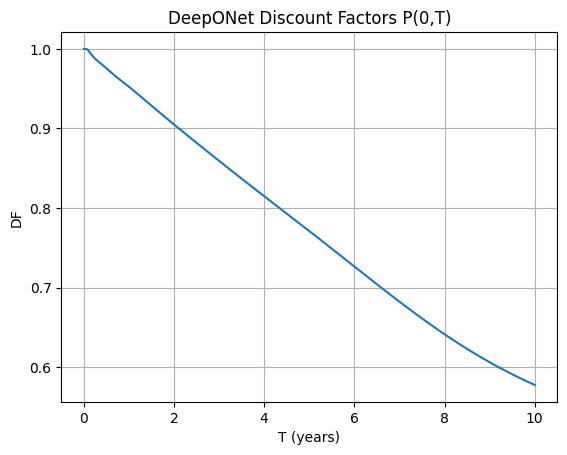

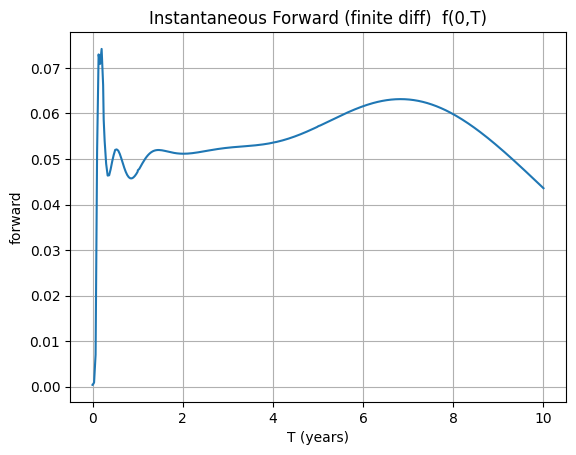

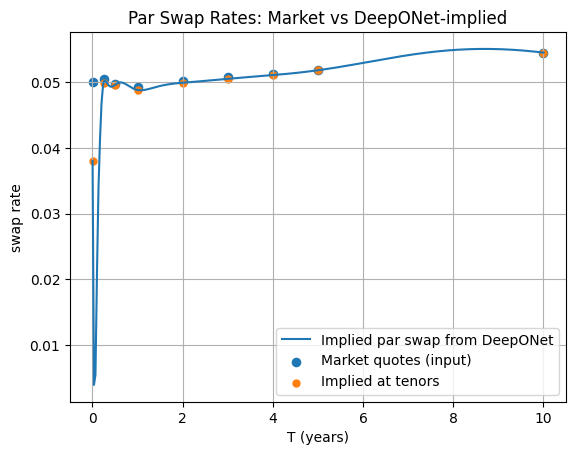

,Tenor_Years,Market_s,DeepONet_implied_s,AbsErr
0,0.002740,0.050000,0.038019,0.011981
1,0.246575,0.050400,0.049932,0.000468
2,0.493151,0.049657,0.049535,0.000122
3,1.000000,0.049174,0.048801,0.000373
4,2.000000,0.050154,0.049900,0.000254
5,3.000000,0.050712,0.050490,0.000222
6,4.000000,0.051270,0.051058,0.000212
7,5.000000,0.051802,0.051795,0.000007
8,10.000000,0.054440,0.054476,0.000036


In [ ]:
T = pred["T"]

plt.figure()
plt.plot(T, pred["P"])
plt.title("DeepONet Discount Factors P(0,T)")
plt.xlabel("T (years)")
plt.ylabel("DF")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(T, pred["fwd"])
plt.title("Instantaneous Forward (finite diff)  f(0,T)")
plt.xlabel("T (years)")
plt.ylabel("forward")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(T, pred["s_imp"], label="Implied par swap from DeepONet")
plt.scatter(T_quote, s_curve, s=35, label="Market quotes (input)")
plt.scatter(T_quote, pred["s_imp_q"], s=25, label="Implied at tenors")
plt.title("Par Swap Rates: Market vs DeepONet-implied")
plt.xlabel("T (years)")
plt.ylabel("swap rate")
plt.grid(True)
plt.legend()
plt.show()

diag = pd.DataFrame({
    "Tenor_Years": T_quote,
    "Market_s": s_curve,
    "DeepONet_implied_s": pred["s_imp_q"],
    "AbsErr": np.abs(pred["s_imp_q"] - s_curve),
})
diag


In [ ]:
# %% 
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [ ]:
# %%
# -----------------------------
# Tenor parsing + Excel loading
# -----------------------------
def tenor_to_years(tenor: str) -> float:
    """
    Parse tenors like '1D','2W','3M','6M','1Y','2Y','10Y' into year fractions.
    Uses simple conversions: 365d, 52w, 12m.
    """
    t = str(tenor).strip().upper()
    m = re.fullmatch(r"(\d+)\s*([DWMY])", t)
    if not m:
        raise ValueError(f"Could not parse tenor: {tenor}")
    n = int(m.group(1))
    u = m.group(2)
    if u == "D":
        return n / 365.0
    if u == "W":
        return n / 52.0
    if u == "M":
        return n / 12.0
    if u == "Y":
        return float(n)
    raise ValueError(f"Unknown tenor unit: {u}")

def load_curve_panel(path: str, index_col="date", dropna=True):
    """
    Reads panel of curves from Excel.
    Returns:
      dates   : index
      T_all   : (n_tenors,) years sorted
      X_all   : (n_dates, n_tenors) rates decimals sorted by tenor
      df      : original dataframe (sorted columns)
    """
    df = pd.read_excel(path, index_col=index_col)
    if dropna:
        df = df.dropna(how="any")

    tenors = list(df.columns)
    T = np.array([tenor_to_years(c) for c in tenors], dtype=float)
    idx = np.argsort(T)
    T = T[idx]
    df = df.iloc[:, idx]

    X = df.values.astype(float)

    # auto-detect percent vs decimal
    if np.nanmax(np.abs(X)) > 1.0:
        X = X / 100.0

    return df.index, T, X, df

# ---- set your path ----
excel_path = "swaps.xlsx"  # <--- change if needed

dates, T_all, X_all, df_raw = load_curve_panel(excel_path, index_col="date", dropna=True)

print("n_dates:", len(dates))
print("n_tenors:", len(T_all))
print("T range:", (T_all.min(), T_all.max()))
df_raw.head()


n_dates: 4430
n_tenors: 9
T range: (np.float64(0.0027397260273972603), np.float64(10.0))


,1d,90d,180d,1y,2y,3y,4y,5y,10y
date,,,,,,,,,
2008-01-02,6.0,6.103718,6.150008,6.110028,6.369943,6.410533,6.430828,6.451124,6.583043
2008-01-03,6.0,6.093868,6.145159,6.098267,6.380091,6.390238,6.410533,6.440976,6.562748
2008-01-04,6.0,6.172664,6.261514,6.213473,6.542452,6.562748,6.583043,6.603339,6.674373
2008-01-07,6.0,6.221904,6.348737,6.344976,6.725113,6.725113,6.714965,6.735261,6.816445
2008-01-08,6.0,6.300675,6.474658,6.420044,6.755557,6.786001,6.796149,6.836741,6.897630


In [ ]:
# %%
# ---------------------------------------
# Split instruments: zeros <=2Y, swaps >2Y
# ---------------------------------------
zero_cutoff = 1.0  # years
zero_mask = T_all <= zero_cutoff
swap_mask = T_all > zero_cutoff

T_zero = T_all[zero_mask]
T_swap = T_all[swap_mask]

print("n_zero:", len(T_zero), "n_swap:", len(T_swap))
print("zero tenors:", T_zero[:10], "...")
print("swap tenors:", T_swap[:10], "...")


n_zero: 4 n_swap: 5
zero tenors: [0.00273973 0.24657534 0.49315068 1.        ] ...
swap tenors: [ 2.  3.  4.  5. 10.] ...


In [ ]:
# %%
# ---------------------------------------------
# Semiannual pay grid for swap pricing (> 2Y)
# Assumes swap maturities align to 0.5y grid.
# Non-aligned maturities are filtered out.
# ---------------------------------------------
dt = 0.5  # semiannual accrual approx

T_max = float(np.max(T_swap)) if len(T_swap) else float(np.max(T_all))
T_pay = np.arange(0.0, T_max + 1e-12, dt)
T_pay[0] = 0.0

# Map each swap maturity to pay-grid index (must align)
tol = 1e-6
swap_to_pay = []
keep_swap = []
for j, Tj in enumerate(T_swap):
    k = int(round(Tj / dt))
    if k < len(T_pay) and abs(T_pay[k] - Tj) < tol:
        swap_to_pay.append(k)
        keep_swap.append(j)

keep_swap = np.array(keep_swap, dtype=int)
swap_to_pay = np.array(swap_to_pay, dtype=int)

# Filter swap instruments to aligned maturities
T_swap_aligned = T_swap[keep_swap]

print("Aligned swaps kept:", len(T_swap_aligned), "out of", len(T_swap))
if len(T_swap_aligned) < len(T_swap):
    print("WARNING: Some swap maturities were not multiples of 0.5y and were dropped.")


Aligned swaps kept: 5 out of 5


In [ ]:
# %%
# ---------------------------------------------
# Torch tensors + column indices for splitting
# ---------------------------------------------
T_pay_t = torch.tensor(T_pay, device=device, dtype=torch.float64).reshape(-1, 1)
swap_to_pay_t = torch.tensor(swap_to_pay, device=device, dtype=torch.long)

zero_idx = torch.tensor(np.where(zero_mask)[0], device=device, dtype=torch.long)
swap_idx_full = np.where(swap_mask)[0]                       # indices in full tenor list
swap_idx = torch.tensor(swap_idx_full[keep_swap], device=device, dtype=torch.long)

T_zero_t = torch.tensor(T_zero, device=device, dtype=torch.float64)  # (n_zero,)


In [ ]:
# %%
# -------------------------
# Dataset with standardization
# -------------------------
class CurveDataset(Dataset):
    def __init__(self, X_all, standardize=True):
        self.X = torch.tensor(X_all, dtype=torch.float64)
        self.standardize = standardize
        if standardize:
            self.mu = self.X.mean(dim=0, keepdim=True)
            self.sig = self.X.std(dim=0, keepdim=True).clamp_min(1e-8)
        else:
            self.mu = torch.zeros(1, self.X.shape[1], dtype=torch.float64)
            self.sig = torch.ones(1, self.X.shape[1], dtype=torch.float64)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        x = self.X[i]
        x_std = (x - self.mu[0]) / self.sig[0] if self.standardize else x
        return x_std, x

dataset = CurveDataset(X_all, standardize=False)

# Split train/test
n = len(dataset)
n_train = int(0.85 * n)
perm = np.random.permutation(n)
train_idx, test_idx = perm[:n_train], perm[n_train:]

train_ds = torch.utils.data.Subset(dataset, train_idx)
test_ds  = torch.utils.data.Subset(dataset, test_idx)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

len(train_ds), len(test_ds)


(3765, 665)

In [ ]:
# %%
# -------------------------
# DeepONet architecture
#   branch(s_curve) + trunk(T) -> g(T;s) -> P=exp(-softplus(g))
# -------------------------
def make_mlp(in_dim, out_dim, hidden=128, depth=3, act=nn.Tanh):
    layers = []
    dims = [in_dim] + [hidden]*depth + [out_dim]
    for i in range(len(dims)-2):
        layers += [nn.Linear(dims[i], dims[i+1]), act()]
    layers += [nn.Linear(dims[-2], dims[-1])]
    return nn.Sequential(*layers)

class DeepONetDiscount(nn.Module):
    def __init__(self, n_tenors, p=64, branch_hidden=128, trunk_hidden=128, depth=3):
        super().__init__()
        self.branch = make_mlp(n_tenors, p, hidden=branch_hidden, depth=depth, act=nn.Tanh)
        self.trunk  = make_mlp(1, p, hidden=trunk_hidden, depth=depth, act=nn.Tanh)
        self.bias = nn.Parameter(torch.zeros(1, dtype=torch.float64))

    def forward(self, x_std, T):
        """
        x_std: (B, n_tenors)
        T: (N, 1)
        returns P: (B, N)
        """
        b = self.branch(x_std)                     # (B, p)
        t = self.trunk(T)                          # (N, p)
        g = torch.einsum("bp,np->bn", b, t) + self.bias
        P = torch.exp(-g)                          # (0,1]
        return P

model = DeepONetDiscount(n_tenors=len(T_all), p=5, branch_hidden=5, trunk_hidden=5, depth=2).to(device)
print("n_params:", sum(p.numel() for p in model.parameters()))


n_params: 181


In [ ]:
# %%
# -----------------------------------------
# Helpers: zero-rate convention & penalties
# -----------------------------------------
def df_from_zero(z, T, convention="cont"):
    """
    z: tensor (B, n) zero rates (decimal)
    T: tensor (1, n) maturities in years
    convention:
      - "cont": P = exp(-z*T)
      - "simple": P = 1 / (1 + z*T)
      - "ann": P = (1+z)^(-T)
    """
    if convention == "cont":
        return torch.exp(-z * T)
    elif convention == "simple":
        return 1.0 / (1.0 + z * T)
    elif convention == "ann":
        return (1.0 + z).pow(-T)
    else:
        raise ValueError("Unknown convention")

def loss_batch_hybrid(model, dataset, x_std, x_raw,
                      zero_convention="cont",
                      w_zero=10.0, w_swap=1.0, w_bc=10.0, w_mono=0.05, w_smooth=0.005):
    """
    x_std, x_raw: (B, n_tenors_all)
    """
    B = x_std.shape[0]

    # ---- ZERO TENORS (<=2Y): fit zero rates in rate-space ----
    if len(T_zero) > 0:
        z_mkt = x_raw[:, zero_idx]                                       # (B, n_zero)
        P_zero = model(x_std, torch.tensor(T_zero, device=device, dtype=torch.float64).reshape(-1,1))  # (B, n_zero)
        # implied continuous zero from model (rate-space)
        z_imp = -torch.log(P_zero) / T_zero_t.reshape(1, -1)
        L_zero = ((z_imp - z_mkt)**2).mean()
    else:
        L_zero = torch.tensor(0.0, device=device, dtype=torch.float64)

    # ---- SWAP TENORS (>2Y): semiannual par swap condition ----
    if len(T_swap_aligned) > 0:
        S_mkt = x_raw[:, swap_idx]                                       # (B, n_swaps_kept)
        P_pay = model(x_std, T_pay_t)                                    # (B, N_pay)

        # boundary P(0)=1
        L_bc = ((P_pay[:, 0] - 1.0)**2).mean()

        # monotonic decreasing on pay grid
        dP = (P_pay[:, 1:] - P_pay[:, :-1]) / dt
        L_mono = torch.relu(dP).pow(2).mean()

        # smoothness on logP curvature along pay grid (helps forward spikes)
        logP = torch.log(P_pay.clamp_min(1e-14))
        d2 = logP[:, 2:] - 2*logP[:, 1:-1] + logP[:, :-2]
        L_smooth = (d2**2).mean()

        # annuity A_k = sum_{i=1..k} dt * P(t_i)
        disc_accr = dt * P_pay[:, 1:]                                    # (B, N_pay-1)
        A_cum = torch.cumsum(disc_accr, dim=1)                            # (B, N_pay-1)

        k = swap_to_pay_t                                                 # (n_swaps_kept,)
        Pk = P_pay[:, k]                                                  # (B, n_swaps_kept)
        Ak = A_cum[:, k-1]                                                # (B, n_swaps_kept)

        par_res = S_mkt * Ak - (1.0 - Pk)
        L_swap = (par_res**2).mean()
    else:
        L_bc = torch.tensor(0.0, device=device, dtype=torch.float64)
        L_mono = torch.tensor(0.0, device=device, dtype=torch.float64)
        L_smooth = torch.tensor(0.0, device=device, dtype=torch.float64)
        L_swap = torch.tensor(0.0, device=device, dtype=torch.float64)

    L = w_zero*L_zero + w_swap*L_swap + w_bc*L_bc + w_mono*L_mono + w_smooth*L_smooth
    parts = {
        "L": float(L.item()),
        "L_zero": float(L_zero.item()),
        "L_swap": float(L_swap.item()),
        "L_bc": float(L_bc.item()),
        "L_mono": float(L_mono.item()),
        "L_smooth": float(L_smooth.item())
    }
    return L, parts


In [ ]:
# %%
# -------------------------
# Train with Adam
# -------------------------
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 20_000
for epoch in range(1, n_epochs + 1):
    model.train()
    train_losses = []
    for x_std, x_raw in train_loader:
        x_std = x_std.to(device)
        x_raw = x_raw.to(device)

        opt.zero_grad()
        L, parts = loss_batch_hybrid(
            model, dataset, x_std, x_raw,
            zero_convention="cont",    # <-- change if your zeros use simple/ann compounding
            w_zero=1.0, w_swap=1.0, w_bc=1.0, w_mono=1, w_smooth=1
        )
        L.backward()
        opt.step()
        train_losses.append(parts["L"])

    if epoch % 25 == 0:
        model.eval()
        with torch.no_grad():
            test_losses = []
            test_parts = []
            for x_std, x_raw in test_loader:
                x_std = x_std.to(device)
                x_raw = x_raw.to(device)
                L, p = loss_batch_hybrid(model, dataset, x_std, x_raw, zero_convention="cont")
                test_losses.append(float(L.item()))
                test_parts.append(p)
        print(f"epoch {epoch:4d}  train {np.mean(train_losses):.3e}  test {np.mean(test_losses):.3e}  "
              f"(test L_zero {np.mean([p['L_zero'] for p in test_parts]):.3e}, L_swap {np.mean([p['L_swap'] for p in test_parts]):.3e})")


epoch   25  train 2.932e-02  test 6.923e-02  (test L_zero 4.502e-03, L_swap 2.421e-02)
epoch   50  train 1.527e-02  test 2.580e-02  (test L_zero 1.237e-03, L_swap 1.343e-02)
epoch   75  train 9.209e-03  test 2.792e-02  (test L_zero 2.202e-03, L_swap 5.897e-03)
epoch  100  train 7.955e-03  test 5.366e-02  (test L_zero 4.890e-03, L_swap 4.767e-03)
epoch  125  train 6.490e-03  test 1.312e-01  (test L_zero 1.268e-02, L_swap 4.314e-03)
epoch  150  train 6.391e-03  test 1.713e-02  (test L_zero 1.344e-03, L_swap 3.684e-03)
epoch  175  train 3.652e-03  test 5.984e-03  (test L_zero 3.936e-04, L_swap 2.048e-03)
epoch  200  train 4.243e-03  test 1.269e-02  (test L_zero 1.104e-03, L_swap 1.656e-03)
epoch  225  train 1.455e-02  test 6.118e-03  (test L_zero 4.436e-04, L_swap 1.682e-03)
epoch  250  train 4.046e-03  test 4.154e-03  (test L_zero 2.851e-04, L_swap 1.303e-03)
epoch  275  train 5.172e-03  test 6.240e-03  (test L_zero 5.048e-04, L_swap 1.191e-03)
epoch  300  train 1.543e-03  test 4.045e-03

KeyboardInterrupt: 

In [ ]:
# %%
# -----------------------------------------
# Prediction helper for a single curve/date
# -----------------------------------------
@torch.no_grad()
def predict_curve(model, dataset, x_curve_raw, zero_convention="cont"):
    """
    x_curve_raw: (n_tenors_all,) rates in decimals
    Returns dict with:
      - pay grid: T_pay, P_pay, semiannual forwards F
      - implied zeros at <=2Y tenors
      - implied par swaps at >2Y aligned tenors
    """
    model.eval()

    x_raw = torch.tensor(np.asarray(x_curve_raw), dtype=torch.float64, device=device).reshape(1, -1)
    x_std = (x_raw - dataset.mu.to(device)) / dataset.sig.to(device)

    # Discount factors on pay grid
    P_pay = model(x_std, T_pay_t)[0]   # (N_pay,)

    # Semiannual forward per period: F_i = (P_{i-1}/P_i - 1)/dt
    F = (P_pay[:-1] / P_pay[1:] - 1.0) / dt

    # Swaps: implied par rates at aligned swap tenors
    if len(T_swap_aligned) > 0:
        disc_accr = dt * P_pay[1:]
        A_cum = torch.cumsum(disc_accr, dim=0)  # (N_pay-1,)
        k = swap_to_pay_t
        Pk = P_pay[k]
        Ak = A_cum[k-1]
        S_imp = (1.0 - Pk) / Ak
    else:
        S_imp = torch.tensor([], device=device, dtype=torch.float64)

    # Zeros: implied continuous zero at zero tenors
    if len(T_zero) > 0:
        P_zero = model(x_std, torch.tensor(T_zero, device=device, dtype=torch.float64).reshape(-1, 1))[0]
        z_imp = -torch.log(P_zero) / T_zero_t
    else:
        z_imp = torch.tensor([], device=device, dtype=torch.float64)

    return {
        "T_pay": np.array(T_pay),
        "P_pay": P_pay.detach().cpu().numpy(),
        "F": F.detach().cpu().numpy(),
        "T_zero": np.array(T_zero),
        "z_imp": z_imp.detach().cpu().numpy(),
        "T_swap": np.array(T_swap_aligned),
        "S_imp": S_imp.detach().cpu().numpy(),
    }

# pick a curve to visualize (test set recommended)
i = int(test_idx[0]) if len(test_idx) else 0
date_i = dates[i]
x_curve = X_all[i]

pred = predict_curve(model, dataset, x_curve, zero_convention="cont")
print("Visualizing date:", date_i)


Visualizing date: 2022-04-06 00:00:00


In [ ]:
# %%
# -------------------------
# Build market arrays for this date
# -------------------------
z_mkt = x_curve[zero_mask]  # zero rates <=2Y
S_mkt = x_curve[swap_mask][keep_swap] if len(T_swap_aligned) else np.array([])

# sanity
print("z_mkt shape:", z_mkt.shape, "S_mkt shape:", S_mkt.shape)


z_mkt shape: (4,) S_mkt shape: (5,)


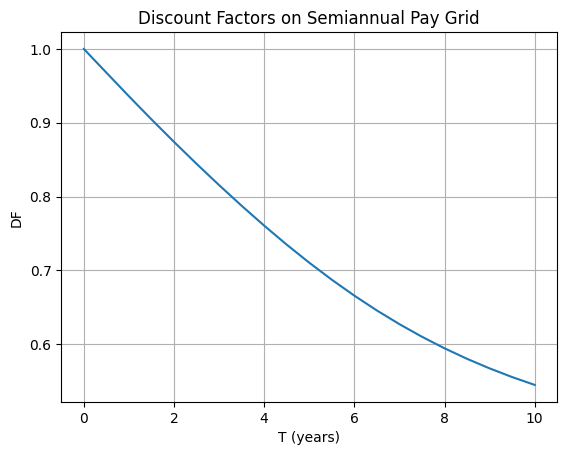

In [ ]:
# %%
# -------------------------
# Plot: Discount Factors
# -------------------------
plt.figure()
plt.plot(pred["T_pay"], pred["P_pay"])
plt.title("Discount Factors on Semiannual Pay Grid")
plt.xlabel("T (years)")
plt.ylabel("DF")
plt.grid(True)
plt.show()


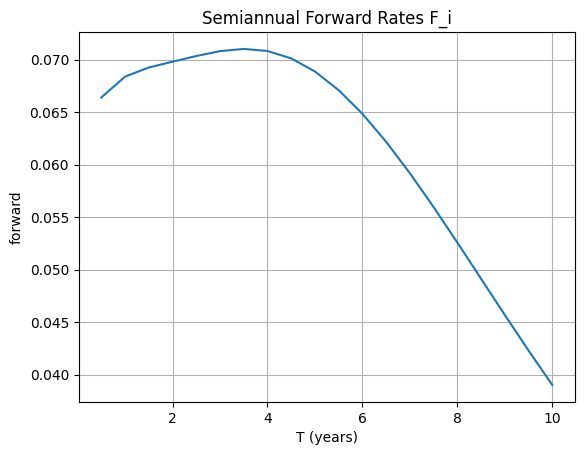

In [ ]:
# %%
# -------------------------
# Plot: Semiannual forwards
# -------------------------
plt.figure()
plt.plot(pred["T_pay"][1:], pred["F"])
plt.title("Semiannual Forward Rates F_i")
plt.xlabel("T (years)")
plt.ylabel("forward")
plt.grid(True)
plt.show()


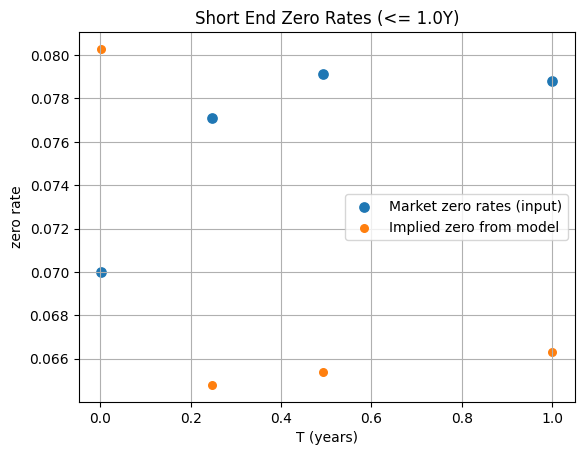

In [ ]:
# %%
# -------------------------
# Plot: Short-end zeros (<=2Y)
# -------------------------
if len(pred["T_zero"]) > 0:
    plt.figure()
    plt.scatter(pred["T_zero"], z_mkt, s=45, label="Market zero rates (input)")
    plt.scatter(pred["T_zero"], pred["z_imp"], s=30, label="Implied zero from model")
    plt.title(f"Short End Zero Rates (<= {zero_cutoff}Y)")
    plt.xlabel("T (years)")
    plt.ylabel("zero rate")
    plt.grid(True)
    plt.legend()
    plt.show()


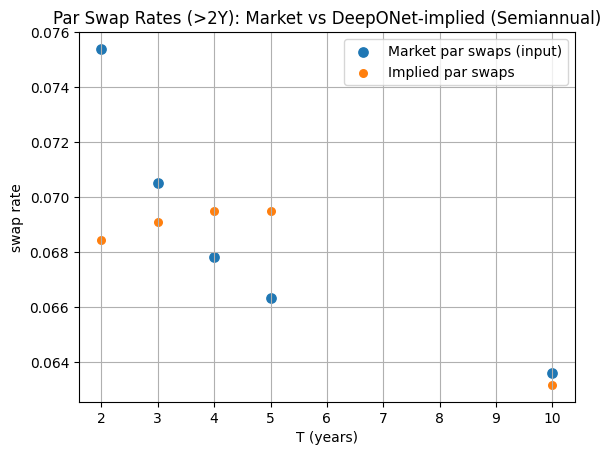

In [ ]:
# %%
# -------------------------
# Plot: Long-end par swaps (>2Y), semiannual
# -------------------------
if len(pred["T_swap"]) > 0:
    plt.figure()
    plt.scatter(pred["T_swap"], S_mkt, s=45, label="Market par swaps (input)")
    plt.scatter(pred["T_swap"], pred["S_imp"], s=30, label="Implied par swaps")
    plt.title("Par Swap Rates (>2Y): Market vs DeepONet-implied (Semiannual)")
    plt.xlabel("T (years)")
    plt.ylabel("swap rate")
    plt.grid(True)
    plt.legend()
    plt.show()


In [ ]:
# %%
# -------------------------
# Diagnostic tables
# -------------------------
if len(pred["T_zero"]) > 0:
    diag_zero = pd.DataFrame({
        "Tenor_Years": pred["T_zero"],
        "Market_Zero": z_mkt,
        "Implied_Zero": pred["z_imp"],
        "AbsErr": np.abs(pred["z_imp"] - z_mkt),
    })
    display(diag_zero)

if len(pred["T_swap"]) > 0:
    diag_swap = pd.DataFrame({
        "Tenor_Years": pred["T_swap"],
        "Market_Swap": S_mkt,
        "Implied_Swap": pred["S_imp"],
        "AbsErr": np.abs(pred["S_imp"] - S_mkt),
    })
    display(diag_swap)


,Tenor_Years,Market_Zero,Implied_Zero,AbsErr
0,0.002740,0.070000,0.080286,0.010286
1,0.246575,0.077100,0.064786,0.012314
2,0.493151,0.079147,0.065380,0.013767
3,1.000000,0.078820,0.066311,0.012509


,Tenor_Years,Market_Swap,Implied_Swap,AbsErr
0,2.0,0.075395,0.068422,0.006974
1,3.0,0.070524,0.069085,0.001438
2,4.0,0.067809,0.069495,0.001686
3,5.0,0.066338,0.069495,0.003157
4,10.0,0.063598,0.063159,0.000439


In [146]:
# Neural ODE curve learner using torchdiffeq.odeint (single Jupyter cell)
# ---------------------------------------------------------------------
# Assumptions:
# - Excel has index_col='date' and tenor columns like '3M','6M','1Y','2Y','3Y',...
# - Tenors <= 2Y are ZERO RATES (fit in rate-space: z_imp(T) = -log P(T) / T)
# - Tenors > 2Y are SEMIANNUAL PAR SWAP RATES (fit via discrete semiannual par condition)
#
# Output:
# - Discount factors on semiannual pay grid
# - Instantaneous forward from ODE (dg/dt)
# - Semiannual forwards from DFs
# - Implied zeros vs market zeros
# - Implied swaps vs market swaps

import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ---- torchdiffeq (odeint) ----
try:
    from torchdiffeq import odeint
except ImportError as e:
    raise ImportError(
        "torchdiffeq is required. Install it in Jupyter with:\n"
        "!pip -q install torchdiffeq\n"
        "Then re-run this cell."
    )

# -----------------------------
# Tenor parsing + Excel loading
# -----------------------------
def tenor_to_years(tenor: str) -> float:
    t = str(tenor).strip().upper()
    m = re.fullmatch(r"(\d+)\s*([DWMY])", t)
    if not m:
        raise ValueError(f"Could not parse tenor: {tenor}")
    n = int(m.group(1)); u = m.group(2)
    if u == "D": return n/365.0
    if u == "W": return n/52.0
    if u == "M": return n/12.0
    if u == "Y": return float(n)
    raise ValueError(f"Unknown tenor unit: {u}")

def load_curve_panel(path: str, index_col="date", dropna=True):
    df = pd.read_excel(path, index_col=index_col)
    if dropna: df = df.dropna(how="any")
    tenors = list(df.columns)
    T = np.array([tenor_to_years(c) for c in tenors], dtype=float)
    idx = np.argsort(T)
    T = T[idx]
    df = df.iloc[:, idx]
    X = df.values.astype(float)
    if np.nanmax(np.abs(X)) > 1.0:
        X = X / 100.0
    return df.index, T, X, df

# ---- set your file ----
excel_path = "swaps.xlsx"  # <-- change
dates, T_all, X_all, df_raw = load_curve_panel(excel_path, index_col="date", dropna=True)
print("n_dates:", len(dates), "n_tenors:", len(T_all), "T_range:", (T_all.min(), T_all.max()))
display(df_raw.head())

# ----------------------------------------------------
# Split: zeros <=2Y, swaps >2Y (semiannual fixed leg)
# ----------------------------------------------------
zero_cutoff = 1.0
zero_mask = T_all <= zero_cutoff
swap_mask = T_all > zero_cutoff

T_zero = T_all[zero_mask]
T_swap = T_all[swap_mask]
print("n_zero:", len(T_zero), "n_swap:", len(T_swap))

# Semiannual payment grid (no stubs) + filter swap maturities that align to 0.5y
dt = 0.5
T_max_swap = float(np.max(T_swap)) if len(T_swap) else float(np.max(T_all))
T_pay = np.arange(0.0, T_max_swap + 1e-12, dt)
T_pay[0] = 0.0

tol = 1e-6
swap_to_pay = []
keep_swap = []
for j, Tj in enumerate(T_swap):
    k = int(round(Tj / dt))
    if k < len(T_pay) and abs(T_pay[k] - Tj) < tol:
        swap_to_pay.append(k)
        keep_swap.append(j)

keep_swap = np.array(keep_swap, dtype=int)
swap_to_pay = np.array(swap_to_pay, dtype=int)
T_swap_aligned = T_swap[keep_swap]
print("Aligned swaps kept:", len(T_swap_aligned), "out of", len(T_swap))
if len(T_swap_aligned) < len(T_swap):
    print("WARNING: Dropped non-aligned swap maturities (not multiples of 0.5y).")

# Indices into the full tenor vector
zero_idx = torch.tensor(np.where(zero_mask)[0], device=device, dtype=torch.long)
swap_idx_full = np.where(swap_mask)[0]
swap_idx = torch.tensor(swap_idx_full[keep_swap], device=device, dtype=torch.long)

# Map swap maturities to pay-grid indices
swap_to_pay_t = torch.tensor(swap_to_pay, device=device, dtype=torch.long)

# ----------------------------------------------------
# ODE evaluation times: union of all needed times + extras
# (cluster near 0 helps short-end)
# ----------------------------------------------------
T_max_global = float(max(T_max_swap, np.max(T_zero) if len(T_zero) else 0.0))
u = np.linspace(0.0, 1.0, 800)
extra = T_max_global * (u**3.0)  # dense near 0
T_eval = np.unique(np.concatenate(([0.0], T_zero, T_pay, extra)))
T_eval.sort()
t_eval = torch.tensor(T_eval, device=device, dtype=torch.float64)  # (N,)

# Build index maps so we can select P at T_zero and T_pay directly (no interpolation needed)
def index_map(all_times, query_times, name=""):
    all_times = np.asarray(all_times)
    query_times = np.asarray(query_times)
    idx = np.searchsorted(all_times, query_times)
    if not np.allclose(all_times[idx], query_times, atol=1e-10, rtol=0):
        raise ValueError(f"Time grid does not contain all query times for {name}.")
    return torch.tensor(idx, device=device, dtype=torch.long)

idx_zero_in_eval = index_map(T_eval, T_zero, name="zeros") if len(T_zero) else torch.tensor([], device=device, dtype=torch.long)
idx_pay_in_eval  = index_map(T_eval, T_pay,  name="paygrid")

T_zero_t = torch.tensor(T_zero, device=device, dtype=torch.float64)  # for z_imp = -logP/T

# -------------------------
# Dataset
# -------------------------
class CurveDataset(Dataset):
    def __init__(self, X_all, standardize=True):
        self.X = torch.tensor(X_all, dtype=torch.float64)
        self.standardize = standardize
        if standardize:
            self.mu = self.X.mean(dim=0, keepdim=True)
            self.sig = self.X.std(dim=0, keepdim=True)
        else:
            self.mu = torch.zeros(1, self.X.shape[1], dtype=torch.float64)
            self.sig = torch.ones(1, self.X.shape[1], dtype=torch.float64)

    def __len__(self): return self.X.shape[0]
    def __getitem__(self, i):
        x = self.X[i]
        x_std = (x - self.mu[0]) / self.sig[0] if self.standardize else x
        return x_std, x

dataset = CurveDataset(X_all, standardize=False)

# train/test split
n = len(dataset)
n_train = int(0.85*n)
perm = np.random.permutation(n)
train_idx, test_idx = perm[:n_train], perm[n_train:]
train_ds = torch.utils.data.Subset(dataset, train_idx)
test_ds  = torch.utils.data.Subset(dataset, test_idx)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)
print("train:", len(train_ds), "test:", len(test_ds))

# -------------------------
# Neural ODE model
# State: g(T) = -log P(T), with g(0)=0
# ODE:   dg/dT = f(T; context)  with f >= 0 via softplus
# Then:  P(T) = exp(-g(T))
# -------------------------
def make_mlp(in_dim, out_dim, hidden=128, depth=3, act=nn.Tanh):
    layers=[]
    dims=[in_dim]+[hidden]*depth+[out_dim]
    for i in range(len(dims)-2):
        layers += [nn.Linear(dims[i], dims[i+1]), act()]
    layers += [nn.Linear(dims[-2], dims[-1])]
    return nn.Sequential(*layers)

class ODEFunc(nn.Module):
    def __init__(self, ctx_dim=64, hidden=128, depth=3):
        super().__init__()
        self.ctx = None
        self.net = make_mlp(1+ctx_dim, 1, hidden=hidden, depth=depth, act=nn.Tanh)
        self.softplus = nn.Softplus(beta=2.0)

    def set_context(self, ctx):  # ctx: (B, ctx_dim)
        self.ctx = ctx

    def forward(self, t, g):     # t: scalar tensor, g: (B,1)
        # broadcast t to batch
        B = g.shape[0]
        t_in = t.expand(B, 1)
        inp = torch.cat([t_in, self.ctx], dim=1)  # (B, 1+ctx_dim)
        f = self.softplus(self.net(inp))          # (B,1), >=0
        return f

class NeuralODECurve(nn.Module):
    def __init__(self, n_tenors, ctx_dim=64, hidden=128, depth=3):
        super().__init__()
        self.enc = make_mlp(n_tenors, ctx_dim, hidden=hidden, depth=depth, act=nn.Tanh)
        self.odefunc = ODEFunc(ctx_dim=ctx_dim, hidden=hidden, depth=depth)

    def solve_g(self, x_std, t_eval, method="rk4", options=None):
        """
        Returns g(t) for all t_eval.
        g: (N, B, 1)
        """
        ctx = self.enc(x_std)          # (B, ctx_dim)
        self.odefunc.set_context(ctx)  # set per-batch context
        g0 = torch.zeros(x_std.shape[0], 1, device=x_std.device, dtype=x_std.dtype)  # g(0)=0
        g = odeint(self.odefunc, g0, t_eval, method=method, options=options)         # (N, B, 1)
        return g

    def P_from_g(self, g):
        return torch.exp(-g.squeeze(-1))  # (N,B)

model = NeuralODECurve(n_tenors=len(T_all), ctx_dim=5, hidden=5, depth=1).to(device)
print("n_params:", sum(p.numel() for p in model.parameters()))

# -------------------------
# Hybrid loss (zeros + swaps) + small forward smoothness
# -------------------------
def loss_batch(model, dataset, x_std, x_raw,
               w_zero=10.0, w_swap=1.0, w_bc=10.0, w_smooth=0.01,
               ode_method="rk4", rk4_step=0.01):
    """
    - Zeros: fit z_imp(T) = -log P(T)/T for T<=2Y
    - Swaps: semiannual par condition for T>2Y (aligned to 0.5y grid)
    """
    # Solve ODE on t_eval
    options = {"step_size": rk4_step} if ode_method == "rk4" else None
    g = model.solve_g(x_std, t_eval, method=ode_method, options=options)     # (N,B,1)
    P_eval = model.P_from_g(g).transpose(0,1)                                # (B,N)

    # boundary P(0)=1 (t_eval[0]=0)
    L_bc = ((P_eval[:, 0] - 1.0)**2).mean()

    # ZEROS loss (rate-space)
    if len(T_zero) > 0:
        z_mkt = x_raw[:, zero_idx]                       # (B,n_zero)
        P_zero = P_eval[:, idx_zero_in_eval]             # (B,n_zero)
        z_imp = -torch.log(P_zero) / T_zero_t.reshape(1, -1)
        L_zero = ((z_imp - z_mkt)**2).mean()
    else:
        L_zero = torch.tensor(0.0, device=device, dtype=torch.float64)

    # SWAPS loss (semiannual par)
    if len(T_swap_aligned) > 0:
        S_mkt = x_raw[:, swap_idx]                       # (B,n_swaps)
        P_pay = P_eval[:, idx_pay_in_eval]               # (B,N_pay)

        disc_accr = dt * P_pay[:, 1:]                    # (B,N_pay-1)
        A_cum = torch.cumsum(disc_accr, dim=1)           # (B,N_pay-1)

        k = swap_to_pay_t
        Pk = P_pay[:, k]                                 # (B,n_swaps)
        Ak = A_cum[:, k-1]                               # (B,n_swaps)

        par_res = S_mkt * Ak - (1.0 - Pk)
        L_swap = (par_res**2).mean()
    else:
        L_swap = torch.tensor(0.0, device=device, dtype=torch.float64)

    # # Forward smoothness (penalize curvature of dg/dt evaluated on a subset of times)
    # # We can approximate forward by calling odefunc at t_eval using current g:
    # # f(t) = odefunc(t, g(t)) (depends on context, ignores g here but fine)
    # # Compute f at eval points (vectorized loop; small cost)
    # # Use maturity weighting so we don't oversmooth the short end.
    # with torch.enable_grad():
    #     # Need forward during training with grads; compute using odefunc directly.
    #     # g currently has grads; odefunc uses context stored from solve_g
    #     # We'll sample every 4th point for speed:
    #     stride = 4
    #     t_sub = t_eval[::stride]
    #     # Re-solve on subsampled grid to keep shapes simple (fast with rk4)
    #     g_sub = model.solve_g(x_std, t_sub, method=ode_method, options=options)  # (Ns,B,1)
    #     # forward at each sub time
    #     f_list = []
    #     for ti, gi in zip(t_sub, g_sub):  # gi: (B,1)
    #         f_list.append(model.odefunc(ti, gi))  # (B,1)
    #     f_sub = torch.stack(f_list, dim=0).squeeze(-1).transpose(0,1)  # (B,Ns)

    #     if f_sub.shape[1] >= 3:
    #         d2 = f_sub[:, 2:] - 2*f_sub[:, 1:-1] + f_sub[:, :-2]
    #         Tmid = t_sub[1:-1]
    #         wT = (Tmid / (Tmid.max() + 1e-18))**1.0
    #         L_smooth = (d2.pow(2) * wT.reshape(1, -1)).mean()
    #     else:
    #         L_smooth = torch.tensor(0.0, device=device, dtype=torch.float64)

    L = w_zero*L_zero + w_swap*L_swap + w_bc*L_bc 
    parts = {"L": float(L.item()), "L_zero": float(L_zero.item()), "L_swap": float(L_swap.item()),
             "L_bc": float(L_bc.item())}
    return L, parts

# -------------------------
# Train
# -------------------------
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# ODE solver settings:
# - rk4 with fixed step is often faster/stabler for training than dopri5
ode_method = "rk4"
rk4_step = 0.01  # try 0.005 if you need more accuracy at short end

n_epochs = 200
for epoch in range(1, n_epochs+1):
    model.train()
    tr = []
    for x_std, x_raw in train_loader:
        x_std = x_std.to(device); x_raw = x_raw.to(device)
        opt.zero_grad()
        L, parts = loss_batch(model, dataset, x_std, x_raw,
                              w_zero=1, w_swap=1, w_bc=1, w_smooth=1,
                              ode_method=ode_method, rk4_step=rk4_step)
        if not torch.isfinite(L):
            raise RuntimeError("Loss became NaN/Inf")
        L.backward()
        opt.step()
        tr.append(parts["L"])

    
    model.eval()
    with torch.no_grad():
        te = []
        te_parts = []
        for x_std, x_raw in test_loader:
            x_std = x_std.to(device); x_raw = x_raw.to(device)
            L, p = loss_batch(model, dataset, x_std, x_raw,
                                ode_method=ode_method, rk4_step=rk4_step)
            te.append(float(L.item())); te_parts.append(p)
    print(f"epoch {epoch:4d}  train {np.mean(tr):.3e}  test {np.mean(te):.3e}  "
            f"(test L_zero {np.mean([p['L_zero'] for p in te_parts]):.3e}, L_swap {np.mean([p['L_swap'] for p in te_parts]):.3e})")



device: cpu
n_dates: 4430 n_tenors: 9 T_range: (np.float64(0.0027397260273972603), np.float64(10.0))


,1d,90d,180d,1y,2y,3y,4y,5y,10y
date,,,,,,,,,
2008-01-02,6.0,6.103718,6.150008,6.110028,6.369943,6.410533,6.430828,6.451124,6.583043
2008-01-03,6.0,6.093868,6.145159,6.098267,6.380091,6.390238,6.410533,6.440976,6.562748
2008-01-04,6.0,6.172664,6.261514,6.213473,6.542452,6.562748,6.583043,6.603339,6.674373
2008-01-07,6.0,6.221904,6.348737,6.344976,6.725113,6.725113,6.714965,6.735261,6.816445
2008-01-08,6.0,6.300675,6.474658,6.420044,6.755557,6.786001,6.796149,6.836741,6.897630


n_zero: 4 n_swap: 5
Aligned swaps kept: 5 out of 5
train: 3765 test: 665
n_params: 121
epoch    1  train 1.926e-01  test 8.849e-02  (test L_zero 7.022e-03, L_swap 1.826e-02)
epoch    2  train 9.854e-03  test 2.175e-02  (test L_zero 1.742e-03, L_swap 4.331e-03)
epoch    3  train 5.550e-03  test 1.736e-02  (test L_zero 1.318e-03, L_swap 4.175e-03)
epoch    4  train 5.074e-03  test 1.548e-02  (test L_zero 1.157e-03, L_swap 3.908e-03)
epoch    5  train 4.692e-03  test 1.355e-02  (test L_zero 9.837e-04, L_swap 3.712e-03)
epoch    6  train 4.325e-03  test 1.215e-02  (test L_zero 8.672e-04, L_swap 3.477e-03)
epoch    7  train 3.994e-03  test 1.098e-02  (test L_zero 7.807e-04, L_swap 3.177e-03)
epoch    8  train 3.600e-03  test 9.593e-03  (test L_zero 6.778e-04, L_swap 2.814e-03)
epoch    9  train 3.100e-03  test 7.934e-03  (test L_zero 5.586e-04, L_swap 2.348e-03)
epoch   10  train 2.515e-03  test 6.177e-03  (test L_zero 4.312e-04, L_swap 1.865e-03)
epoch   11  train 1.999e-03  test 5.007e-03

KeyboardInterrupt: 

Visualizing: 2019-06-17 00:00:00


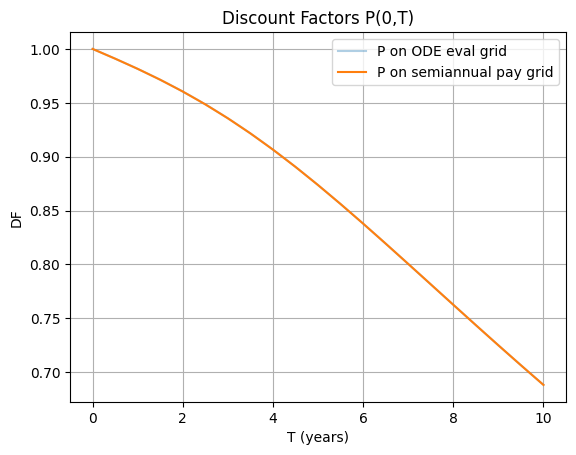

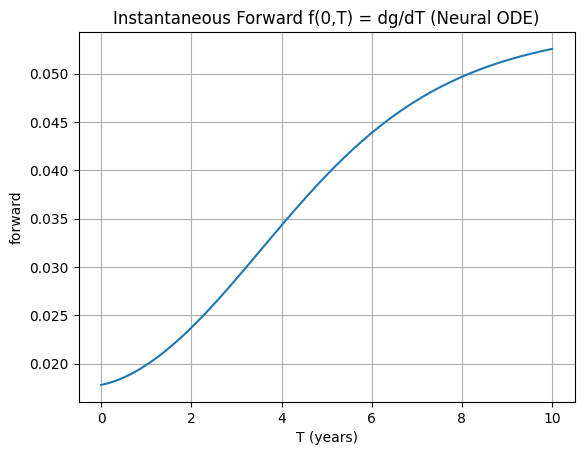

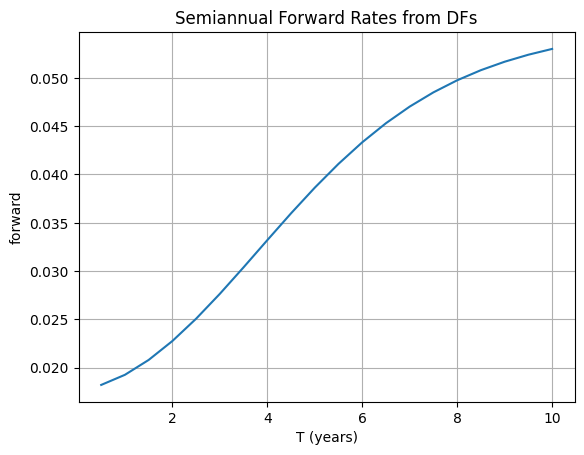

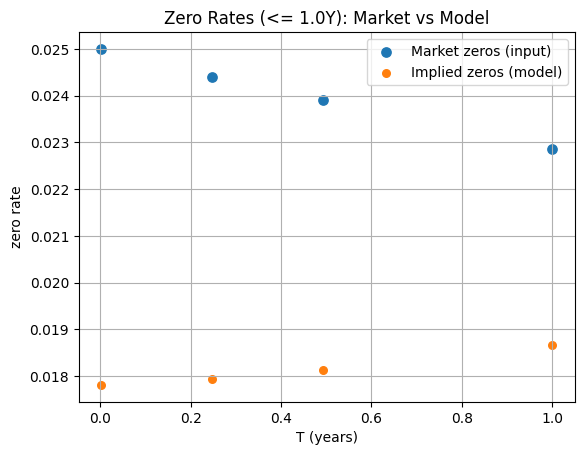

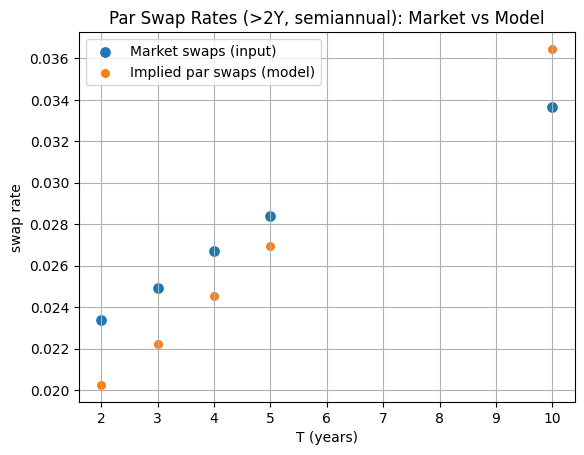

,Tenor_Years,Market_Zero,Implied_Zero,AbsErr
0,0.002740,0.025000,0.017811,0.007189
1,0.246575,0.024400,0.017948,0.006452
2,0.493151,0.023907,0.018136,0.005771
3,1.000000,0.022862,0.018661,0.004202


,Tenor_Years,Market_Swap,Implied_Swap,AbsErr
0,2.0,0.023399,0.020249,0.003150
1,3.0,0.024946,0.022237,0.002709
2,4.0,0.026721,0.024530,0.002191
3,5.0,0.028420,0.026931,0.001488
4,10.0,0.033643,0.036456,0.002813


In [147]:
# -------------------------
# Predict/plot for one date
# -------------------------
@torch.no_grad()
def predict_one(i):
    x_curve = X_all[i]
    x_raw = torch.tensor(x_curve, device=device, dtype=torch.float64).reshape(1, -1)
    x_std = (x_raw - dataset.mu.to(device)) / dataset.sig.to(device)

    g = model.solve_g(x_std, t_eval, method=ode_method, options={"step_size": rk4_step} if ode_method=="rk4" else None)
    P_eval = model.P_from_g(g).squeeze(1)  # (N,) since B=1 -> (N,)

    # forward at eval points
    f_list=[]
    for ti, gi in zip(t_eval, g.squeeze(1)):  # gi: (1,)
        f_list.append(model.odefunc(ti, gi.reshape(1,1)).squeeze(1))
    f_eval = torch.stack(f_list, dim=0).squeeze(-1)  # (N,)

    # pay-grid DFs
    P_pay = P_eval[idx_pay_in_eval]
    F_pay = (P_pay[:-1] / P_pay[1:] - 1.0) / dt

    # implied zeros
    if len(T_zero):
        P_zero = P_eval[idx_zero_in_eval]
        z_imp = (-torch.log(P_zero) / T_zero_t).cpu().numpy()
    else:
        z_imp = np.array([])

    # implied swaps
    if len(T_swap_aligned):
        disc_accr = dt * P_pay[1:]
        A_cum = torch.cumsum(disc_accr, dim=0)
        k = swap_to_pay_t
        Pk = P_pay[k]
        Ak = A_cum[k-1]
        S_imp = ((1.0 - Pk) / Ak).cpu().numpy()
    else:
        S_imp = np.array([])

    return {
        "date": dates[i],
        "T_eval": T_eval,
        "P_eval": P_eval.cpu().numpy(),
        "f_eval": f_eval.cpu().numpy(),
        "T_pay": T_pay,
        "P_pay": P_pay.cpu().numpy(),
        "F_pay": F_pay.cpu().numpy(),
        "T_zero": T_zero,
        "z_imp": z_imp,
        "T_swap": T_swap_aligned,
        "S_imp": S_imp,
        "z_mkt": x_curve[zero_mask],
        "S_mkt": x_curve[swap_mask][keep_swap] if len(T_swap_aligned) else np.array([]),
    }

i = int(test_idx[0]) if len(test_idx) else 0
pred = predict_one(i)
print("Visualizing:", pred["date"])

# DF plot
plt.figure()
plt.plot(pred["T_eval"], pred["P_eval"], alpha=0.35, label="P on ODE eval grid")
plt.plot(pred["T_pay"], pred["P_pay"], label="P on semiannual pay grid")
plt.title("Discount Factors P(0,T)")
plt.xlabel("T (years)"); plt.ylabel("DF"); plt.grid(True); plt.legend(); plt.show()

# Instantaneous forward (ODE)
plt.figure()
plt.plot(pred["T_eval"], pred["f_eval"])
plt.title("Instantaneous Forward f(0,T) = dg/dT (Neural ODE)")
plt.xlabel("T (years)"); plt.ylabel("forward"); plt.grid(True); plt.show()

# Semiannual forwards
plt.figure()
plt.plot(pred["T_pay"][1:], pred["F_pay"])
plt.title("Semiannual Forward Rates from DFs")
plt.xlabel("T (years)"); plt.ylabel("forward"); plt.grid(True); plt.show()

# Zeros comparison
if len(pred["T_zero"]):
    plt.figure()
    plt.scatter(pred["T_zero"], pred["z_mkt"], s=45, label="Market zeros (input)")
    plt.scatter(pred["T_zero"], pred["z_imp"], s=30, label="Implied zeros (model)")
    plt.title(f"Zero Rates (<= {zero_cutoff}Y): Market vs Model")
    plt.xlabel("T (years)"); plt.ylabel("zero rate"); plt.grid(True); plt.legend(); plt.show()

# Swaps comparison
if len(pred["T_swap"]):
    plt.figure()
    plt.scatter(pred["T_swap"], pred["S_mkt"], s=45, label="Market swaps (input)")
    plt.scatter(pred["T_swap"], pred["S_imp"], s=30, label="Implied par swaps (model)")
    plt.title("Par Swap Rates (>2Y, semiannual): Market vs Model")
    plt.xlabel("T (years)"); plt.ylabel("swap rate"); plt.grid(True); plt.legend(); plt.show()

# Diagnostics
if len(pred["T_zero"]):
    diag_zero = pd.DataFrame({
        "Tenor_Years": pred["T_zero"],
        "Market_Zero": pred["z_mkt"],
        "Implied_Zero": pred["z_imp"],
        "AbsErr": np.abs(pred["z_imp"] - pred["z_mkt"]),
    })
    display(diag_zero)

if len(pred["T_swap"]):
    diag_swap = pd.DataFrame({
        "Tenor_Years": pred["T_swap"],
        "Market_Swap": pred["S_mkt"],
        "Implied_Swap": pred["S_imp"],
        "AbsErr": np.abs(pred["S_imp"] - pred["S_mkt"]),
    })
    display(diag_swap)
